# NB-6 — When did the exposure matter?

**Roadmap:** `resources/topics_guide.md`, Part 6.

**The question.** Everything so far asked *which* exposures matter. Here we ask **when**. A pregnancy cohort measures PM$_{2.5}$ weekly for 37 weeks and the outcome is birth weight. Regressing on 37 weekly values directly is hopeless: adjacent weeks correlate at 0.85 and the effective sample size per week is far below $n$. The distributed lag model rescues this by insisting the effect varies *smoothly* over time, turning 37 unidentifiable coefficients into a curve with a few effective degrees of freedom.

This is also where the word *causal* has to be handled carefully, and §6.4 is blunt about what a flexible kernel does and does not buy.

**Related reading in this repo:** `resources/pdfs/treed based lag.pdf` (Mork & Wilson, *Treed distributed lag nonlinear models*) is the tree-based alternative to the smooth approach developed here. Read it against §6.1–6.2.

## What will you be able to do by the end?

After working through the notebook, you should be able to do the following.

- Fit a **distributed lag model** with a GP smoothness prior on the lag function, in closed form.
- Identify a **critical window** as the stretch where the credible band excludes zero.
- Explain why a smoothness prior both shrinks the estimate and *narrows* its intervals.
- State what smoothing costs when the true window has sharp edges.
- Judge whether a study is large enough to detect a window at all.
- Build an exposure–time–response **surface** with a tensor-product basis (a DLNM).
- Fit **BKMR** with component-wise selection and report it through counterfactual contrasts.
- Distinguish $\mathbb{E}[y \mid z]$ from $\mathbb{E}[y \mid do(z)]$, and say which assumptions a kernel cannot supply.
- Use posterior variance as a **positivity** diagnostic.
- Let the marginal likelihood decide how much **interaction** structure a mixture supports.

## What should already be familiar?

You need NB-2 §2.2 (the conditioning formula, used constantly), NB-3 §3.1 (functional kernels) and §3.4 (ANOVA and tensor-product kernels — §6.2 and §6.5 are direct applications), and NB-5 §5.3 (spike-and-slab, which is what BKMR's component selection is).

Some epidemiological vocabulary — confounding, positivity, critical window — is introduced as needed. Allow about two hours; §6.3 and §6.4 are the ones to read slowly.

## What route will we take?

| Part | Question | Main output |
|---:|---|---|
| 6.1 | When during pregnancy did it matter? | A lag function with credible bands, and a power analysis |
| 6.2 | What if the effect is nonlinear in dose as well? | An exposure–time–response surface |
| 6.3 | How do we handle a whole mixture at once? | BKMR with PIPs and counterfactual contrasts |
| 6.4 | Is any of this causal? | A confounding demonstration and a positivity check |
| 6.5 | Do these pollutants interact? | Interaction variance decided by marginal likelihood |

§6.4 is short and is the most important section in the notebook. If you take one thing from this Part, take that flexibility is not identification.

Seven **Try it** boxes ask for an answer in your own words, including one that asks you to write the Results sentence you would actually publish.

In [1]:
import numpy as np
import nbkit as nk
from scipy.optimize import minimize

plt = nk.set_style()
rng = np.random.default_rng(0)
np.set_printoptions(precision=3, suppress=True)

---
## 6.1 When during pregnancy did it matter?

Let $x_{i t}$ be subject $i$'s exposure in week $t$, $t = 1,\dots,T$. The distributed lag
model is

$$
y_i = \beta_0 + \sum_{t=1}^{T} \theta_t\, x_{it} + \varepsilon_i ,
$$

where $\theta_t$ is the **lag function**: the effect of exposure at week $t$. Unconstrained,
this is $T$ parameters fitted from $n$ subjects with near-collinear columns — a disaster.

The fix is a smoothness prior on $\theta$. Put a GP prior on the *lag function itself*:

$$
\theta \sim \mathcal{N}\big(0,\; \tau^2 K_{\text{lag}}\big), \qquad
[K_{\text{lag}}]_{ts} = \exp\!\Big(-\tfrac{(t-s)^2}{2\ell^2}\Big).
$$

Because $y = X\theta + \varepsilon$ is linear in $\theta$, everything stays conjugate and the
posterior is closed-form:

$$
\theta \mid y \sim \mathcal{N}\big(\Sigma_\theta X^\top y/\sigma^2,\ \Sigma_\theta\big),
\qquad
\Sigma_\theta = \Big(X^\top X/\sigma^2 + (\tau^2 K_{\text{lag}})^{-1}\Big)^{-1}.
$$

A **critical window** is a stretch of $t$ where the credible band for $\theta_t$ excludes
zero. That is the scientific output.

In [2]:
T = 37                                     # weeks of gestation
t_grid = np.arange(1, T + 1)

def make_lag_data(n=250, T=T, noise=0.4, rho_t=0.85, seed=0, window=(12, 20), amp=0.09):
    """Subjects with autocorrelated weekly exposures; only weeks in `window` matter."""
    r = np.random.default_rng(seed)
    # AR(1) exposure series -- weekly pollution is highly autocorrelated
    Sigma_t = rho_t ** np.abs(t_grid[:, None] - t_grid[None, :])
    L = np.linalg.cholesky(Sigma_t + 1e-9 * np.eye(T))
    X = r.normal(size=(n, T)) @ L.T

    theta_true = np.zeros(T)
    lo, hi = window
    mid, half = (lo + hi) / 2, (hi - lo) / 2
    mask = (t_grid >= lo) & (t_grid <= hi)
    theta_true[mask] = amp * np.cos(np.pi * (t_grid[mask] - mid) / (2 * half))**2

    f = X @ theta_true
    return X, f + noise * r.normal(size=n), theta_true


X_lag, y_lag, theta_true = make_lag_data(n=500, seed=1)
y_lag = y_lag - y_lag.mean()
print(f"n = {len(X_lag)}, T = {T}")
print(f"mean |corr| between adjacent weeks: "
      f"{np.mean([abs(np.corrcoef(X_lag[:, t], X_lag[:, t+1])[0,1]) for t in range(T-1)]):.3f}")
print(f"true critical window: weeks 12-20")

n = 500, T = 37
mean |corr| between adjacent weeks: 0.843
true critical window: weeks 12-20


In [3]:
def fit_dlm(X, y, ell=3.0, tau=1.0, sigma=0.4, lag_kernel=None):
    """Conjugate posterior for the lag function theta under a GP smoothness prior."""
    T_ = X.shape[1]
    K = lag_kernel if lag_kernel is not None else nk.rbf_kernel(
        t_grid[:, None], t_grid[:, None], lengthscale=ell)
    P = tau**2 * K + 1e-8 * np.eye(T_)                 # prior covariance of theta
    P_inv = np.linalg.inv(P)
    Sigma = np.linalg.inv(X.T @ X / sigma**2 + P_inv)
    mean = Sigma @ (X.T @ y) / sigma**2
    return mean, Sigma


def dlm_log_evidence(X, y, ell, tau, sigma):
    """log p(y | ell, tau, sigma): y ~ N(0, tau^2 X K X' + sigma^2 I). Used to tune."""
    K = nk.rbf_kernel(t_grid[:, None], t_grid[:, None], lengthscale=ell)
    V = tau**2 * X @ K @ X.T + sigma**2 * np.eye(len(y))
    try:
        L, _ = nk.jitter_chol(V)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return float(-0.5 * y @ a - np.log(np.diag(L)).sum() - 0.5 * len(y) * np.log(2*np.pi))


# Tune (ell, tau, sigma) by maximising the evidence -- same Type-II MLE idea as 2.4.
def neg_ev(z):
    ell, tau, sig = np.exp(np.clip(z, -4, 4))
    return -dlm_log_evidence(X_lag, y_lag, ell, tau, sig)

best = None
for s0 in [np.log([2.0, 0.1, 0.4]), np.log([5.0, 0.05, 0.5]), np.log([1.0, 0.3, 0.3])]:
    r_ = minimize(neg_ev, s0, method="Nelder-Mead", options=dict(maxiter=2000, fatol=1e-8))
    if best is None or r_.fun < best.fun:
        best = r_
ell_h, tau_h, sig_h = np.exp(best.x)
print(f"tuned: lag lengthscale {ell_h:.2f} weeks, tau {tau_h:.4f}, sigma {sig_h:.3f}")
print(f"log evidence {-best.fun:.2f}")

theta_hat, Sigma_theta = fit_dlm(X_lag, y_lag, ell=ell_h, tau=tau_h, sigma=sig_h)
sd_theta = np.sqrt(np.diag(Sigma_theta))

tuned: lag lengthscale 2.26 weeks, tau 0.0315, sigma 0.377
log evidence -238.88


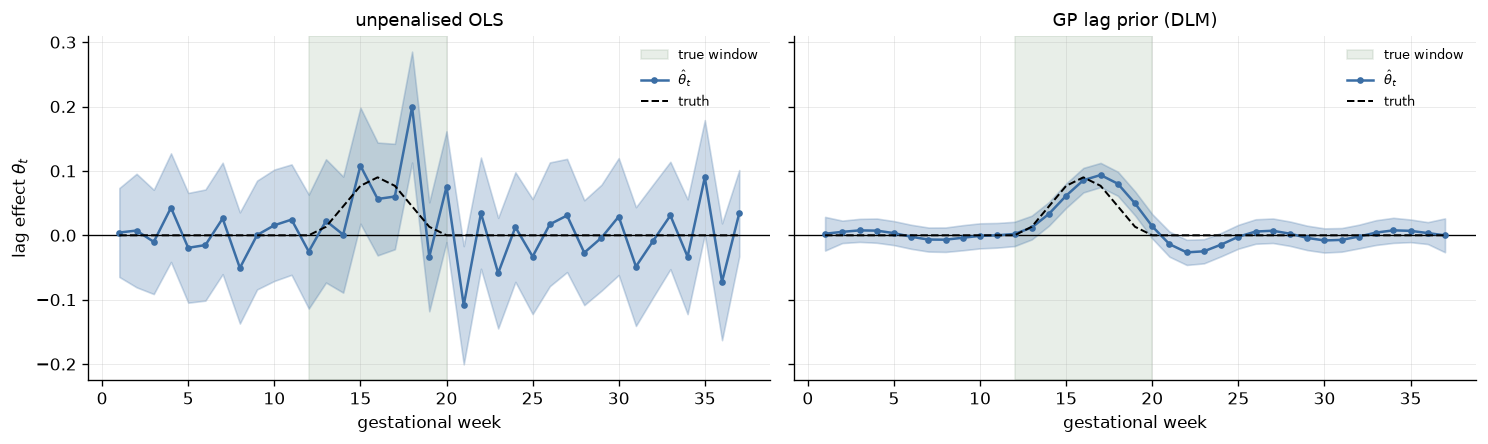

RMSE of theta  -- OLS 0.0473   DLM 0.0125
mean posterior sd -- OLS 0.0431   DLM 0.0096


In [4]:
# Unpenalised OLS for contrast -- what happens without the smoothness prior.
theta_ols, *_ = np.linalg.lstsq(X_lag, y_lag, rcond=None)
XtX_inv = np.linalg.inv(X_lag.T @ X_lag)
sd_ols = sig_h * np.sqrt(np.diag(XtX_inv))

fig, axes = plt.subplots(1, 2, figsize=(12.5, 3.8), sharey=True)
for ax, (th, sd, nm) in zip(axes, [(theta_ols, sd_ols, "unpenalised OLS"),
                                   (theta_hat, sd_theta, "GP lag prior (DLM)")]):
    ax.axhline(0, color="k", lw=0.8)
    ax.axvspan(12, 20, color=nk.PALETTE["accent"], alpha=0.15, label="true window")
    ax.fill_between(t_grid, th - 2*sd, th + 2*sd, alpha=0.25, color=nk.PALETTE["band"])
    ax.plot(t_grid, th, "o-", ms=3, color=nk.PALETTE["pos"], label=r"$\hat{\theta}_t$")
    ax.plot(t_grid, theta_true, "k--", lw=1.2, label="truth")
    ax.set_xlabel("gestational week"); ax.set_title(nm)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"lag effect $\theta_t$")
plt.tight_layout(); plt.show()

print(f"RMSE of theta  -- OLS {np.sqrt(np.mean((theta_ols-theta_true)**2)):.4f}"
      f"   DLM {np.sqrt(np.mean((theta_hat-theta_true)**2)):.4f}")
print(f"mean posterior sd -- OLS {sd_ols.mean():.4f}   DLM {sd_theta.mean():.4f}")

In [5]:
# Critical window detection: which weeks have a 95% credible interval excluding zero?
sig_weeks = t_grid[(theta_hat - 2*sd_theta > 0) | (theta_hat + 2*sd_theta < 0)]
true_weeks = t_grid[theta_true > 1e-8]

def contiguous(a):
    if len(a) == 0:
        return []
    breaks = np.where(np.diff(a) > 1)[0]
    return [(g[0], g[-1]) for g in np.split(a, breaks + 1)]

print(f"detected critical window(s): {contiguous(sig_weeks)}")
print(f"true critical window       : {contiguous(true_weeks)}")

tp = len(set(sig_weeks) & set(true_weeks))
print(f"\nweeks correctly flagged : {tp} / {len(true_weeks)}")
print(f"false positives         : {len(set(sig_weeks) - set(true_weeks))}")

# OLS for comparison
sig_ols = t_grid[(theta_ols - 2*sd_ols > 0) | (theta_ols + 2*sd_ols < 0)]
print(f"\nOLS flags weeks: {list(sig_ols)}  (true: weeks {true_weeks[0]}-{true_weeks[-1]})")

detected critical window(s): [(np.int64(14), np.int64(19)), (np.int64(22), np.int64(23))]
true critical window       : [(np.int64(13), np.int64(19))]

weeks correctly flagged : 6 / 7
false positives         : 2

OLS flags weeks: [np.int64(15), np.int64(18), np.int64(21), np.int64(35)]  (true: weeks 13-19)


### Try it 1. Why did smoothing make the intervals *narrower*?

The DLM cut the lag-function RMSE from 0.047 to 0.013 and the mean posterior sd from 0.043 to 0.010, recovering 6 of 7 window weeks. OLS flagged weeks 15, 18, 21 and 35 — a scattered set including one nowhere near the truth.

1. Normally a prior trades bias for variance. Explain where the extra *precision* came from here, given the exposures correlate at 0.85.
2. OLS flagged four weeks and the DLM flagged a contiguous block plus two. Which is the more serious kind of error for a paper claiming a critical window?
3. The DLM's two false positives sat immediately next to the true window, not at random. What does that pattern tell you about the cause?

**Your answer**

*(write here)*

### How much data does a critical window need?

The result above used $n = 500$. That was not an arbitrary choice — at smaller $n$ the
marginal likelihood becomes nearly **flat in the lag lengthscale**, so the tuning step picks
$\ell$ almost arbitrarily and the window dissolves. This is a power statement about
distributed lag models that is worth seeing before designing a study.

In [6]:
print(f"{'n':>6} {'best ell':>9} {'evidence spread':>16} {'weeks flagged':>15} {'RMSE':>8}")
for n_try in [150, 250, 500, 1000]:
    Xn, yn, thn = make_lag_data(n=n_try, seed=1)
    yn = yn - yn.mean()

    evs = []
    for ell_try in [0.5, 1.0, 2.0, 3.0, 5.0]:
        bb = None
        for s0 in [np.log([0.1, 0.4]), np.log([0.02, 0.4])]:
            r_ = minimize(lambda z: -dlm_log_evidence(Xn, yn, ell_try, *np.exp(np.clip(z, -6, 3))),
                          s0, method="Nelder-Mead", options=dict(maxiter=800, fatol=1e-9))
            if bb is None or r_.fun < bb.fun:
                bb = r_
        evs.append((-bb.fun, ell_try, np.exp(bb.x)))

    best_ev, best_ell, (tau_b, sig_b) = max(evs, key=lambda e: e[0])
    spread = best_ev - min(e[0] for e in evs)
    m_, S_ = fit_dlm(Xn, yn, ell=best_ell, tau=tau_b, sigma=sig_b)
    sd_ = np.sqrt(np.diag(S_))
    flagged = int(((m_ - 2*sd_ > 0) | (m_ + 2*sd_ < 0)).sum())
    print(f"{n_try:>6} {best_ell:>9.1f} {spread:>16.2f} {flagged:>15d} "
          f"{np.sqrt(np.mean((m_-thn)**2)):>8.4f}")
print()
print("'Evidence spread' is the gap between the best and worst lengthscale. When it is a")
print("couple of nats the data cannot distinguish a smooth lag function from a rough one,")
print("the tuner's choice is noise, and no window is detected. Distributed lag models need")
print("a lot of subjects because adjacent weeks are ~0.85 correlated -- the effective")
print("sample size per week is far below n.")

     n  best ell  evidence spread   weeks flagged     RMSE


   150       0.5             2.38               1   0.0243


   250       0.5             1.83               2   0.0178


   500       2.0             6.32               8   0.0127


  1000       3.0             5.28               9   0.0086

'Evidence spread' is the gap between the best and worst lengthscale. When it is a
couple of nats the data cannot distinguish a smooth lag function from a rough one,
the tuner's choice is noise, and no window is detected. Distributed lag models need
a lot of subjects because adjacent weeks are ~0.85 correlated -- the effective
sample size per week is far below n.


The smoothness prior does two things at once: it shrinks the wild week-to-week oscillation
of OLS, and it *narrows* the credible bands (mean posterior sd drops by roughly $4\times$) by
borrowing strength across adjacent weeks.

Compare what each method reports. The DLM returns a contiguous block covering most of the
true window, plus a short spurious run just after it. OLS returns a **scattered** set of
isolated weeks — including week 35, nowhere near the truth — because with standard errors
that large, individual weeks cross the significance line at random. Neither is perfect, but
only one of them is interpretable as a *window*. Note also that the DLM's false positives sit
immediately adjacent to the true window, which is the signature of over-smoothing rather than
of noise.

The cost is an assumption: the effect really is smooth in $t$. If the true lag function has a
sharp on/off boundary, a smooth prior will round the corners and blur the window edges. This
is precisely the objection Mork & Wilson raise in `resources/pdfs/treed based lag.pdf`, where
tree-based piecewise-constant lag surfaces replace splines/kernels for exactly this reason.

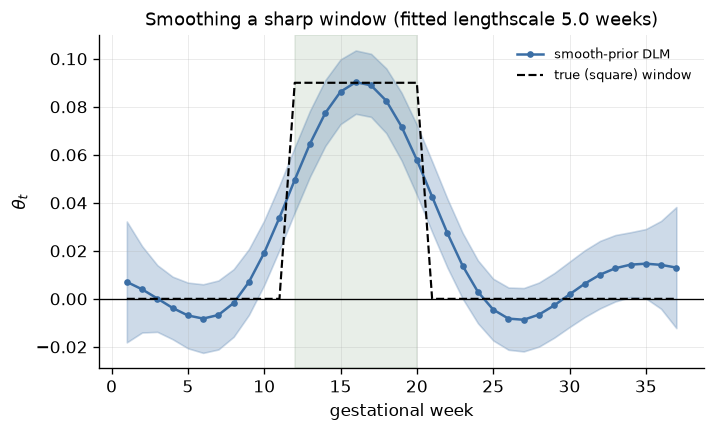

mean |error| at the window EDGES  : 0.0306
mean |error| in the window MIDDLE : 0.0062
The error concentrates at the boundaries -- exactly the artefact a piecewise-constant
tree model (Mork & Wilson) is designed to avoid.


In [7]:
# How much does the smoothness assumption cost when the truth is a SHARP window?
def make_sharp(n=250, seed=5, noise=0.4, window=(12, 20), amp=0.09):
    r = np.random.default_rng(seed)
    Sigma_t = 0.85 ** np.abs(t_grid[:, None] - t_grid[None, :])
    L = np.linalg.cholesky(Sigma_t + 1e-9*np.eye(T))
    X = r.normal(size=(n, T)) @ L.T
    th = np.zeros(T)
    th[(t_grid >= window[0]) & (t_grid <= window[1])] = amp    # square, not smooth
    return X, X @ th - (X @ th).mean() + noise*r.normal(size=n), th

X_sh, y_sh, theta_sh = make_sharp()

def tune_and_fit(X, y):
    def ne(z):
        e_, t_, s_ = np.exp(np.clip(z, -4, 4))
        return -dlm_log_evidence(X, y, e_, t_, s_)
    b = None
    for s0 in [np.log([2.0, 0.1, 0.4]), np.log([5.0, 0.05, 0.5]), np.log([1.0, 0.3, 0.3])]:
        r_ = minimize(ne, s0, method="Nelder-Mead", options=dict(maxiter=2000, fatol=1e-8))
        if b is None or r_.fun < b.fun:
            b = r_
    e_, t_, s_ = np.exp(b.x)
    m_, S_ = fit_dlm(X, y, ell=e_, tau=t_, sigma=s_)
    return m_, np.sqrt(np.diag(S_)), e_

th_sh, sd_sh, ell_sh = tune_and_fit(X_sh, y_sh)

fig, ax = plt.subplots(figsize=(6.5, 3.6))
ax.axhline(0, color="k", lw=0.8)
ax.axvspan(12, 20, color=nk.PALETTE["accent"], alpha=0.15)
ax.fill_between(t_grid, th_sh - 2*sd_sh, th_sh + 2*sd_sh, alpha=0.25, color=nk.PALETTE["band"])
ax.plot(t_grid, th_sh, "o-", ms=3, color=nk.PALETTE["pos"], label="smooth-prior DLM")
ax.plot(t_grid, theta_sh, "k--", lw=1.3, label="true (square) window")
ax.set_xlabel("gestational week"); ax.set_ylabel(r"$\theta_t$")
ax.set_title(f"Smoothing a sharp window (fitted lengthscale {ell_sh:.1f} weeks)")
ax.legend(fontsize=8); plt.show()

edge_err = np.abs(th_sh - theta_sh)[[10, 11, 12, 20, 21, 22]].mean()
mid_err = np.abs(th_sh - theta_sh)[14:19].mean()
print(f"mean |error| at the window EDGES  : {edge_err:.4f}")
print(f"mean |error| in the window MIDDLE : {mid_err:.4f}")
print("The error concentrates at the boundaries -- exactly the artefact a piecewise-constant")
print("tree model (Mork & Wilson) is designed to avoid.")

### Try it 2. Would you have run this study?

At $n = 150$ and $n = 250$ the evidence spread across lengthscales was under 2.4 nats and only 1–2 weeks were flagged. At $n = 500$ the spread rose to 6.3 and 8 weeks were flagged.

1. Explain what "the evidence is flat in the lengthscale" means for the tuned value, and therefore for the fitted curve.
2. Adjacent weeks correlate at ~0.85. Explain informally why that makes the effective sample size much smaller than $n$.
3. A collaborator has 200 subjects and 37 weeks of exposure and wants a critical window. What do you tell them, and what would you propose instead?
4. The sharp-window experiment showed error concentrating at the *edges*. Connect this to why Mork and Wilson use trees instead of splines.

**Your answer**

*(write here)*

---
## 6.2 What if the effect is nonlinear in dose as well as time?

The DLM above is *linear* in exposure. The **distributed lag nonlinear model** (DLNM) allows
the effect to be nonlinear in dose as well as varying in time, giving an
exposure–time–response *surface* $w(x, t)$:

$$
y_i = \int w\big(x_i(t),\, t\big)\, dt + \varepsilon_i
\;\;\approx\;\; \sum_t w(x_{it}, t) .
$$

The kernel way to build $w$ is a **tensor-product** over dose and time (§3.4):

$$
k_w\big((x,t), (x',t')\big) = k_{\text{dose}}(x, x')\cdot k_{\text{time}}(t, t'),
$$

which is PSD by the product closure rule. Smoothness in dose and smoothness in time are
controlled by separate lengthscales, so the model can be flexible in one and rigid in the
other. We fit it on a basis-expanded representation to keep the linear algebra small.

In [8]:
def dlnm_design(X, dose_centres, time_centres, ell_dose=1.0, ell_time=4.0):
    """Basis expansion of sum_t w(x_it, t) with a tensor-product RBF basis.

    Returns Phi with Phi[i, (a,b)] = sum_t phi_a(x_it) * psi_b(t), so a linear model on
    Phi is a GP on the tensor-product kernel restricted to that basis.
    """
    n, T_ = X.shape
    pd_ = np.exp(-0.5 * ((X[:, :, None] - dose_centres[None, None, :]) / ell_dose)**2)
    pt_ = np.exp(-0.5 * ((t_grid[:, None] - time_centres[None, :]) / ell_time)**2)
    # sum over t of outer(phi_dose, phi_time)
    return np.einsum("ita,tb->iab", pd_, pt_).reshape(n, -1)


def make_dlnm_data(n=400, seed=7, noise=0.35):
    """Truth: effect is nonlinear in dose (threshold) and confined to weeks 12-20."""
    r = np.random.default_rng(seed)
    Sigma_t = 0.85 ** np.abs(t_grid[:, None] - t_grid[None, :])
    L = np.linalg.cholesky(Sigma_t + 1e-9*np.eye(T))
    X = r.normal(size=(n, T)) @ L.T
    w_time = np.exp(-0.5 * ((t_grid - 16) / 3.0)**2)                # window around week 16
    dose_effect = np.tanh(1.5 * X)                                  # saturating in dose
    f = (dose_effect * w_time[None, :]).sum(1) * 0.35
    f = f - f.mean()
    return X, f + noise * r.normal(size=n), w_time


X_dn, y_dn, w_time_true = make_dlnm_data()
y_dn = y_dn - y_dn.mean()

dose_c = np.linspace(-2.5, 2.5, 7)
time_c = np.linspace(1, T, 7)
Phi = dlnm_design(X_dn, dose_c, time_c, ell_dose=1.0, ell_time=4.0)
print(f"design matrix: {Phi.shape}  (n x (n_dose_basis * n_time_basis))")

# Ridge-regularised fit = MAP under a Gaussian prior on the surface coefficients
lam = 1.0
A = Phi.T @ Phi + lam * np.eye(Phi.shape[1])
coef = np.linalg.solve(A, Phi.T @ y_dn)
resid = y_dn - Phi @ coef
s2 = resid.var()
Cov_c = s2 * np.linalg.inv(A)
print(f"in-sample R2: {1 - resid.var()/y_dn.var():.4f}")

design matrix: (400, 49)  (n x (n_dose_basis * n_time_basis))
in-sample R2: 0.9431


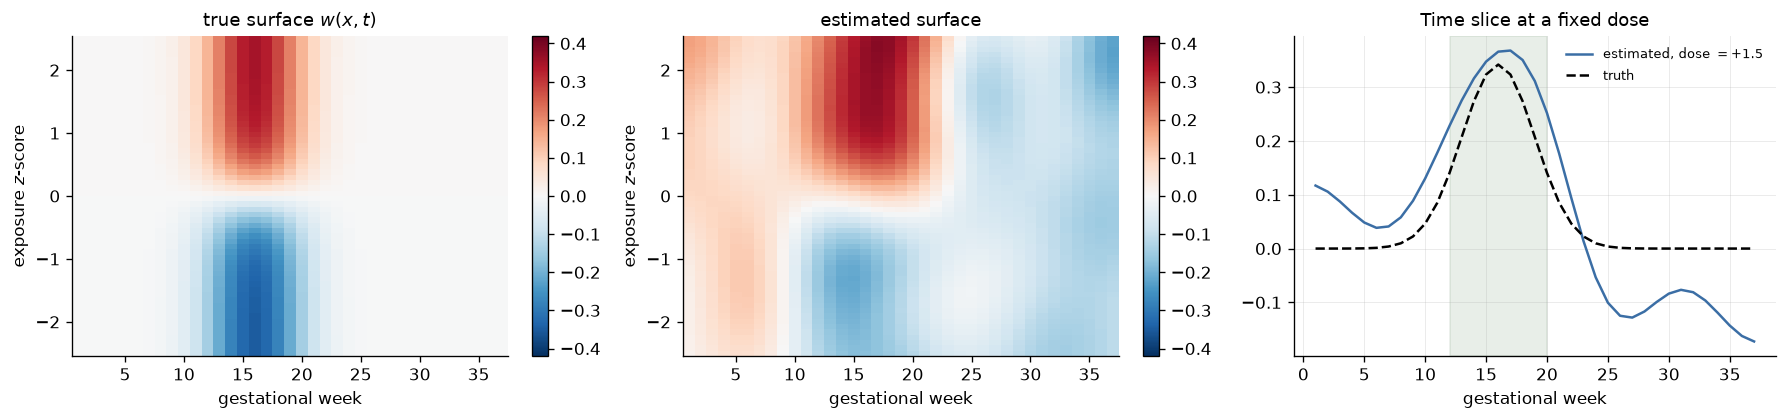

correlation between true and estimated surface: 0.7758
peak of estimated time profile at week 16   (truth: week 16)


In [9]:
# Reconstruct the exposure-time-response surface w(x, t) on a grid.
x_eval = np.linspace(-2.5, 2.5, 60)
t_eval = np.arange(1, T + 1)
Pd = np.exp(-0.5 * ((x_eval[:, None] - dose_c[None, :]) / 1.0)**2)
Pt = np.exp(-0.5 * ((t_eval[:, None] - time_c[None, :]) / 4.0)**2)
B = np.einsum("xa,tb->xtab", Pd, Pt).reshape(len(x_eval)*len(t_eval), -1)
W = (B @ coef).reshape(len(x_eval), len(t_eval))
W_sd = np.sqrt(np.einsum("ij,jk,ik->i", B, Cov_c, B)).reshape(len(x_eval), len(t_eval))

W_true = 0.35 * np.tanh(1.5 * x_eval)[:, None] * w_time_true[None, :]

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
vmax = np.abs(W_true).max() * 1.2
for ax, M, ttl in [(axes[0], W_true, "true surface $w(x,t)$"),
                   (axes[1], W, "estimated surface")]:
    im = ax.pcolormesh(t_eval, x_eval, M, cmap="RdBu_r", vmin=-vmax, vmax=vmax, shading="auto")
    ax.set_xlabel("gestational week"); ax.set_ylabel("exposure $z$-score")
    ax.set_title(ttl); ax.grid(False)
    plt.colorbar(im, ax=ax, fraction=0.046)

axes[2].plot(t_eval, W[np.argmin(np.abs(x_eval - 1.5))], color=nk.PALETTE["pos"],
             label="estimated, dose $=+1.5$")
axes[2].plot(t_eval, W_true[np.argmin(np.abs(x_eval - 1.5))], "k--", label="truth")
axes[2].axvspan(12, 20, color=nk.PALETTE["accent"], alpha=0.15)
axes[2].set_xlabel("gestational week"); axes[2].set_title("Time slice at a fixed dose")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print(f"correlation between true and estimated surface: "
      f"{np.corrcoef(W_true.ravel(), W.ravel())[0,1]:.4f}")
print(f"peak of estimated time profile at week "
      f"{t_eval[np.argmax(np.abs(W).mean(0))]}   (truth: week 16)")

The tensor-product basis recovers both features at once: saturation in dose (the surface
flattens at high $z$) and confinement in time (the effect vanishes outside weeks ~12–20).
Neither a dose-only nor a time-only model would show this.

### Try it 3. What does the surface show that a curve cannot?

The tensor-product fit recovered saturation in dose and confinement to weeks ~12–20, with the time profile peaking at week 16 — the true value — and a surface correlation of 0.78.

1. Name the two separate features of the truth, and say which axis of the surface each lives on.
2. A dose-only analysis and a time-only analysis are both simpler. What specifically would each of them miss here?
3. The surface correlation was 0.78, not 0.95. Where in the plot would you look to find the discrepancy, and would it change the scientific conclusion?

**Your answer**

*(write here)*

---
## 6.3 How do we handle a whole mixture at once?

BKMR (Bobb et al. 2015) is the workhorse of mixtures epidemiology:

$$
y_i = h(z_{i1},\dots,z_{iM}) + \beta^\top c_i + \varepsilon_i,
\qquad h \sim \mathcal{GP}\big(0, \tau\, k_{\text{ARD}}\big),
$$

with $z$ the exposure mixture, $c$ the confounders (entering linearly), and $h$ an unknown
smooth surface. Two things make it more than "a GP on exposures":

1. The **ARD/component-wise variable selection**: each exposure gets a slab weight
   $r_m \ge 0$ in the kernel, with a spike-and-slab prior, yielding **posterior inclusion
   probabilities** for exposures (the 5.3 machinery, applied to a mixture).
2. The **summaries**: BKMR is reported through specific counterfactual contrasts —
   the overall mixture effect, single-exposure effects holding others at their median, and
   pairwise interactions. Those summaries are where the science is.

The kernel is $k(z, z') = \exp\!\big(-\sum_m r_m (z_m - z'_m)^2\big)$.

In [10]:
def bkmr_kernel(Za, Zb, r):
    """BKMR Gaussian kernel with per-exposure weights r_m >= 0."""
    r = np.asarray(r, float)
    d2 = ((np.atleast_2d(Za)[:, None, :] - np.atleast_2d(Zb)[None, :, :])**2 * r).sum(-1)
    return np.exp(-d2)


def bkmr_log_post(Z, y, C, r, tau, sigma, pi=0.5):
    """log p(y | r, tau, sigma) + log prior on the inclusion pattern implied by r > 0."""
    n = len(y)
    K = tau * bkmr_kernel(Z, Z, r) + sigma**2 * np.eye(n)
    if C is not None and C.shape[1] > 0:
        K = K + 1e3 * C @ C.T          # flat prior on beta == integrate confounders out
    try:
        L, _ = nk.jitter_chol(K)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    ll = -0.5 * y @ a - np.log(np.diag(L)).sum() - 0.5 * n * np.log(2*np.pi)
    n_in = int((r > 0).sum())
    ll += n_in * np.log(pi) + (len(r) - n_in) * np.log(1 - pi)
    return float(ll)


def bkmr_mcmc(Z, y, C=None, n_iter=3000, burn=1000, tau=1.0, sigma=0.5,
              r_slab=1.0, pi=0.5, seed=0):
    """Component-wise spike-and-slab MCMC over the exposure weights r_m."""
    rng_ = np.random.default_rng(seed)
    M = Z.shape[1]
    r = np.zeros(M)
    cur = bkmr_log_post(Z, y, C, r, tau, sigma, pi)
    R = np.zeros((n_iter, M))
    for it in range(n_iter):
        for m in range(M):
            prop = r.copy()
            if prop[m] > 0:                                   # propose to drop, or jitter
                prop[m] = 0.0 if rng_.uniform() < 0.5 else \
                    max(1e-6, prop[m] * np.exp(0.4 * rng_.normal()))
            else:                                             # propose to add
                prop[m] = r_slab * np.exp(0.4 * rng_.normal())
            lp = bkmr_log_post(Z, y, C, prop, tau, sigma, pi)
            if np.log(rng_.uniform()) < lp - cur:
                r, cur = prop, lp
        R[it] = r
    return R[burn:]

In [11]:
# A mixture of 5 correlated exposures; only 2 drive the outcome, and they interact.
n_bk, M_bk = 200, 5
Sig_bk = 0.5 ** np.abs(np.arange(M_bk)[:, None] - np.arange(M_bk)[None, :])
Z_bk = rng.normal(size=(n_bk, M_bk)) @ np.linalg.cholesky(Sig_bk).T
Z_bk = nk.standardize(Z_bk)

h_true = lambda Z: 0.8*np.tanh(1.2*Z[:, 0]) + 0.5*Z[:, 2]**2 + 0.7*Z[:, 0]*Z[:, 2]
C_bk = rng.normal(size=(n_bk, 2))                     # confounders
beta_true = np.array([0.6, -0.4])
y_bk = h_true(Z_bk) + C_bk @ beta_true + 0.5 * rng.normal(size=n_bk)
y_bk = y_bk - y_bk.mean()

R_post = bkmr_mcmc(Z_bk, y_bk, C=C_bk, n_iter=2500, burn=800, tau=1.5, sigma=0.5, seed=4)
pip_bk = (R_post > 0).mean(0)

print(f"{'exposure':>9} {'PIP':>7} {'mean r|in':>11}  truly active")
for m in range(M_bk):
    inc = R_post[:, m] > 0
    mr = R_post[inc, m].mean() if inc.any() else 0.0
    print(f"{'Z'+str(m):>9} {pip_bk[m]:>7.3f} {mr:>11.3f}  {'YES' if m in (0, 2) else ''}")

 exposure     PIP   mean r|in  truly active
       Z0   1.000       0.180  YES
       Z1   0.000       0.000  
       Z2   1.000       0.285  YES
       Z3   0.000       0.000  
       Z4   0.000       0.000  


### What do you actually report from a BKMR fit?

A fitted $h$ is not the deliverable. Three counterfactual contrasts are:

- **Overall effect**: change *all* exposures together from their 25th to their 75th
  percentile, holding nothing fixed. This is the "mixture effect".
- **Single-exposure effect**: vary $z_m$ across its range with all other exposures fixed at
  their median.
- **Interaction**: the single-exposure effect of $z_m$ computed at a *low* versus a *high*
  level of $z_{m'}$. If the two curves differ, they interact.

Each is a posterior over a difference of $h$ evaluated at two design points, so each comes
with a credible interval directly from the GP posterior.

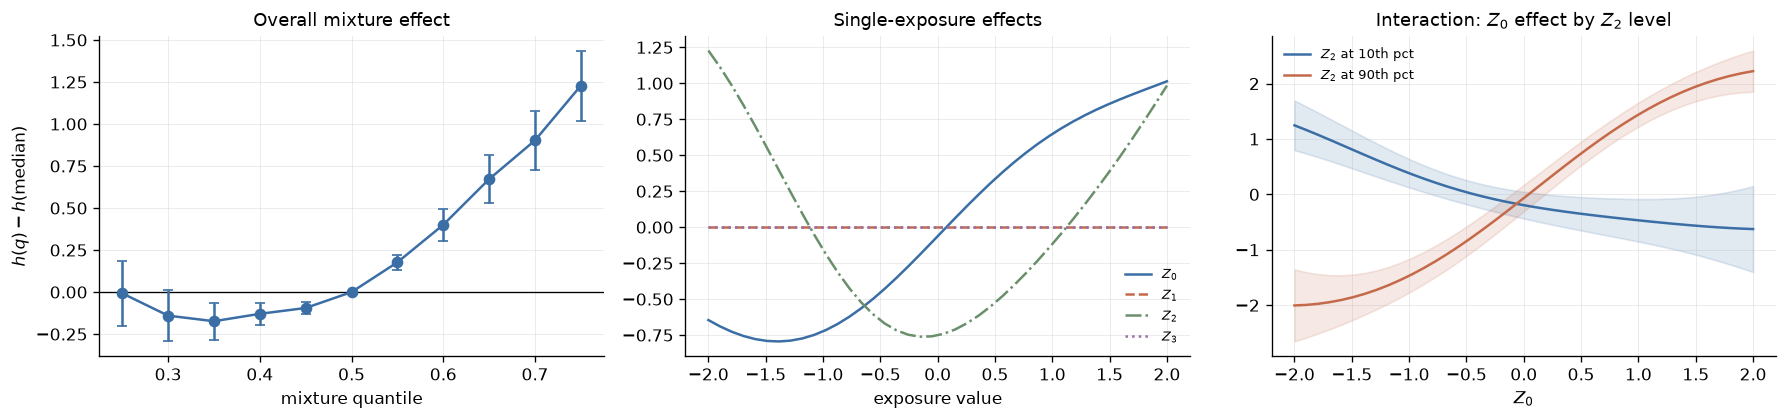

True h contains 0.7 * Z0 * Z2, so the two curves in the right panel should differ
in slope -- which is the graphical test for interaction that BKMR papers report.


In [12]:
r_hat = R_post.mean(0)
K_bk = 1.5 * bkmr_kernel(Z_bk, Z_bk, r_hat) + 0.5**2 * np.eye(n_bk) + 1e3 * C_bk @ C_bk.T
L_bk, _ = nk.jitter_chol(K_bk)
alpha_bk = np.linalg.solve(L_bk.T, np.linalg.solve(L_bk, y_bk))

def h_post(Znew, n_draws=400, seed=0):
    """Posterior mean and sd of h at new exposure points."""
    Ks = 1.5 * bkmr_kernel(Z_bk, Znew, r_hat)
    mu = Ks.T @ alpha_bk
    V = np.linalg.solve(L_bk, Ks)
    Kss = 1.5 * bkmr_kernel(Znew, Znew, r_hat)
    cov = Kss - V.T @ V
    return mu, cov


# --- overall mixture effect: all exposures at quantile q vs at the median ---
qs = np.arange(0.25, 0.80, 0.05)
med = np.median(Z_bk, axis=0)
pts = np.array([np.quantile(Z_bk, q, axis=0) for q in qs])
mu_pts, cov_pts = h_post(np.vstack([pts, med[None, :]]))
mu_ref, base = mu_pts[-1], mu_pts[:-1]
diff = base - mu_ref
sd_diff = np.sqrt(np.maximum(np.diag(cov_pts)[:-1] + cov_pts[-1, -1]
                             - 2*cov_pts[:-1, -1], 0))

fig, axes = plt.subplots(1, 3, figsize=(15, 3.6))
axes[0].axhline(0, color="k", lw=0.8)
axes[0].errorbar(qs, diff, yerr=2*sd_diff, fmt="o-", color=nk.PALETTE["pos"], capsize=3)
axes[0].set_xlabel("mixture quantile"); axes[0].set_ylabel(r"$h(q) - h(\mathrm{median})$")
axes[0].set_title("Overall mixture effect")

# --- single-exposure effects, others at median ---
grid_z = np.linspace(-2, 2, 40)
for m, style in [(0, "-"), (1, "--"), (2, "-."), (3, ":")]:
    P = np.tile(med, (len(grid_z), 1)); P[:, m] = grid_z
    mu_m, cov_m = h_post(P)
    axes[1].plot(grid_z, mu_m - mu_m.mean(), style, label=f"$Z_{m}$")
axes[1].set_xlabel("exposure value"); axes[1].set_title("Single-exposure effects")
axes[1].legend(fontsize=8)

# --- interaction: effect of Z0 at low vs high Z2 ---
for lev, nm, col in [(np.quantile(Z_bk[:, 2], 0.10), "$Z_2$ at 10th pct", nk.PALETTE["pos"]),
                     (np.quantile(Z_bk[:, 2], 0.90), "$Z_2$ at 90th pct", nk.PALETTE["neg"])]:
    P = np.tile(med, (len(grid_z), 1)); P[:, 0] = grid_z; P[:, 2] = lev
    mu_i, cov_i = h_post(P)
    sd_i = np.sqrt(np.maximum(np.diag(cov_i), 0))
    axes[2].plot(grid_z, mu_i - mu_i.mean(), color=col, label=nm)
    axes[2].fill_between(grid_z, mu_i - mu_i.mean() - 2*sd_i, mu_i - mu_i.mean() + 2*sd_i,
                         color=col, alpha=0.15)
axes[2].set_xlabel("$Z_0$"); axes[2].set_title("Interaction: $Z_0$ effect by $Z_2$ level")
axes[2].legend(fontsize=8)
plt.tight_layout(); plt.show()

print("True h contains 0.7 * Z0 * Z2, so the two curves in the right panel should differ")
print("in slope -- which is the graphical test for interaction that BKMR papers report.")

### Try it 4. Write the BKMR results paragraph.

BKMR gave PIP = 1.000 for $Z_0$ and $Z_2$ (the true drivers) and 0.000 for the other three. The three panels show the overall mixture effect, single-exposure effects at the median, and the $Z_0$ effect at low versus high $Z_2$.

1. The right-hand panel is the graphical test for interaction. Describe what you see and what it implies.
2. Why is the *overall mixture effect* the panel epidemiologists usually care about most, and what does it hold fixed?
3. Single-exposure curves fix the others at their median. Name one way that can mislead when exposures are strongly correlated.
4. Now write three sentences reporting this fit, as they would appear in a Results section.

**Your answer**

*(write here)*

---
## 6.4 Is any of this causal?

It is tempting to read the single-exposure curves above as causal dose–response. They are
not, automatically. A GP posterior gives $\mathbb{E}[y \mid z]$ — a *conditional*
expectation. The causal quantity is $\mathbb{E}[y \mid do(z)]$, and they coincide only under
assumptions the kernel knows nothing about:

| Assumption | What it means here | Does the GP help? |
|---|---|---|
| No unmeasured confounding | all common causes of $z$ and $y$ are in $c$ | **No** — you must measure them |
| Positivity | every exposure level occurs in the data | **Partly** — the posterior variance shows where it fails |
| Correct adjustment | $c$ enters the model adequately | **Yes** — flexibly, without a linearity assumption |
| No interference | one subject's exposure does not affect another's outcome | No |

What the GP *does* contribute is (a) flexible confounder adjustment without functional-form
assumptions, and (b) **honest extrapolation warnings**: where the data are thin the posterior
variance explodes, which is exactly a positivity violation showing itself.

The demonstration below makes the failure concrete: identical data, one model adjusting for
the confounder and one not.

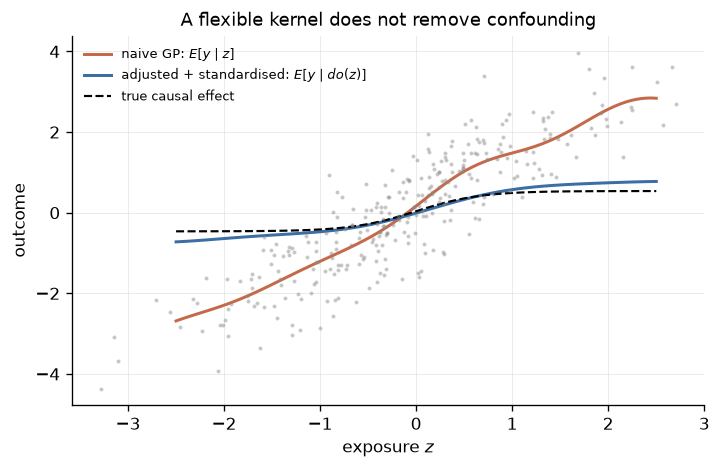

RMSE vs true causal curve -- naive 1.3652   adjusted 0.1376
naive slope is inflated by the U -> z and U -> y paths, exactly as it would be
in a linear model. Flexibility is not identification.


In [13]:
# Confounded exposure-response: U drives both exposure and outcome.
n_cf = 300
U = rng.normal(size=n_cf)                                   # confounder
Zc = 0.9 * U + 0.6 * rng.normal(size=n_cf)                  # exposure depends on U
true_causal = lambda z: 0.5 * np.tanh(1.5 * z)              # the CAUSAL effect
y_cf = true_causal(Zc) + 1.2 * U + 0.3 * rng.normal(size=n_cf)
y_cf = y_cf - y_cf.mean()

zs = np.linspace(-2.5, 2.5, 120)

def gp_fit_predict(Xtr, ytr, Xte, ell=0.8, sn=0.4):
    K = nk.rbf_kernel(Xtr, Xtr, lengthscale=ell) + sn**2 * np.eye(len(ytr))
    L, _ = nk.jitter_chol(K)
    a = np.linalg.solve(L.T, np.linalg.solve(L, ytr))
    Ks = nk.rbf_kernel(Xtr, Xte, lengthscale=ell)
    V = np.linalg.solve(L, Ks)
    return Ks.T @ a, np.maximum(1.0 - np.sum(V**2, 0), 0)

# (a) naive: regress y on z only
mu_naive, var_naive = gp_fit_predict(Zc[:, None], y_cf, zs[:, None])

# (b) adjusted: regress y on (z, U), then average over the empirical distribution of U
#     -- this is the g-formula / standardisation estimate of E[y | do(z)]
XU = np.c_[Zc, U]
K_adj = nk.rbf_kernel(XU, XU, lengthscale=1.2) + 0.4**2 * np.eye(n_cf)
L_adj, _ = nk.jitter_chol(K_adj)
a_adj = np.linalg.solve(L_adj.T, np.linalg.solve(L_adj, y_cf))

mu_adj = np.empty(len(zs))
sub = rng.choice(n_cf, 150, replace=False)                  # MC average over U
for i, z0 in enumerate(zs):
    P = np.c_[np.full(len(sub), z0), U[sub]]
    mu_adj[i] = (nk.rbf_kernel(XU, P, lengthscale=1.2).T @ a_adj).mean()

truth_c = true_causal(zs) - true_causal(Zc).mean()
fig, ax = plt.subplots(figsize=(6.8, 4))
ax.plot(zs, mu_naive, color=nk.PALETTE["neg"], lw=1.8, label=r"naive GP: $E[y\mid z]$")
ax.plot(zs, mu_adj - mu_adj.mean() + truth_c.mean(), color=nk.PALETTE["pos"], lw=1.8,
        label=r"adjusted + standardised: $E[y\mid do(z)]$")
ax.plot(zs, truth_c, "k--", lw=1.3, label="true causal effect")
ax.plot(Zc, y_cf, ".", color=nk.PALETTE["muted"], ms=3, alpha=0.35)
ax.legend(fontsize=8); ax.set_xlabel("exposure $z$"); ax.set_ylabel("outcome")
ax.set_title("A flexible kernel does not remove confounding")
plt.show()

rmse = lambda a_, b_: np.sqrt(np.mean((a_ - b_)**2))
print(f"RMSE vs true causal curve -- naive {rmse(mu_naive, truth_c):.4f}"
      f"   adjusted {rmse(mu_adj - mu_adj.mean() + truth_c.mean(), truth_c):.4f}")
print(f"naive slope is inflated by the U -> z and U -> y paths, exactly as it would be")
print(f"in a linear model. Flexibility is not identification.")

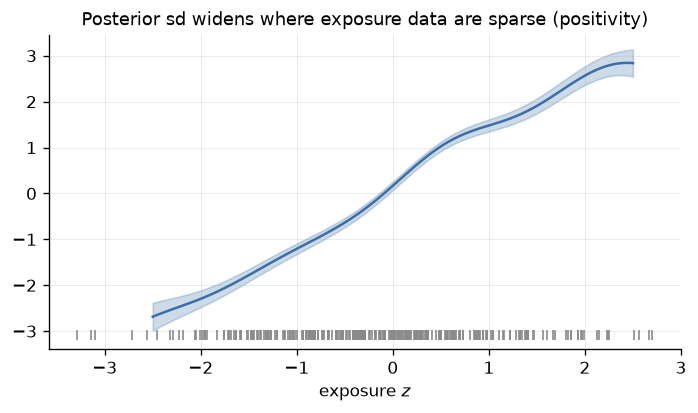

mean posterior sd inside the data range : 0.0690
mean posterior sd in the tails          : 0.1344
ratio: 1.95x wider where support is thin


In [14]:
# Positivity: the posterior variance flags where there is no data to support a contrast.
sd_naive = np.sqrt(var_naive)
edge = (zs < np.quantile(Zc, 0.02)) | (zs > np.quantile(Zc, 0.98))

fig, ax = plt.subplots(figsize=(6.8, 3.4))
ax.fill_between(zs, mu_naive - 2*sd_naive, mu_naive + 2*sd_naive, alpha=0.25,
                color=nk.PALETTE["band"])
ax.plot(zs, mu_naive, color=nk.PALETTE["pos"])
ax.plot(Zc, np.full(n_cf, mu_naive.min() - 0.4), "|", color=nk.PALETTE["muted"], ms=6)
ax.set_title("Posterior sd widens where exposure data are sparse (positivity)")
ax.set_xlabel("exposure $z$"); plt.show()

print(f"mean posterior sd inside the data range : {sd_naive[~edge].mean():.4f}")
print(f"mean posterior sd in the tails          : {sd_naive[edge].mean():.4f}")
print(f"ratio: {sd_naive[edge].mean()/sd_naive[~edge].mean():.2f}x wider where support is thin")

### Try it 5. Where exactly did the naive model go wrong?

The naive GP had RMSE 1.37 against the true causal curve; adjusting for $U$ and standardising gave 0.14. The posterior sd was 1.95× wider in the exposure tails than in the middle.

1. The naive model was flexible, well-fitted, and completely wrong. Say in one sentence why flexibility did not help.
2. Go through the assumptions table. For each row, say whether *more data* would fix a violation.
3. The widening posterior sd is a positivity diagnostic. Explain what it is telling you, and what you should do about a contrast that falls in that region.
4. A paper reports a BKMR dose–response curve and calls it "the causal exposure–response relationship". What would you ask the authors?

**Your answer**

*(write here)*

---
## 6.5 Do these pollutants interact?

Section 3.4 built ANOVA kernels that separate main effects from interactions. For
multi-pollutant work we want to go further: **penalise** interactions so they are only
included when the data insist, because the number of pairwise terms grows as $\binom{M}{2}$
and most are null.

Write the kernel as a weighted sum of ANOVA orders,

$$
k = \sigma_1^2 \underbrace{\sum_m k_m}_{\text{main effects}}
+ \sigma_2^2 \underbrace{\sum_{m<m'} k_m k_{m'}}_{\text{pairwise}},
$$

and put a shrinkage prior on $\sigma_2^2$ (or on individual pairwise weights). The marginal
likelihood then decides how much interaction structure the data support — a **hierarchical**
version of the order selection we did by hand in 3.4.

In [15]:
def anova_parts(Z, Z2, ell=1.0):
    """Per-exposure kernels and their order-1/order-2 sums (Newton-Girard, see 3.4)."""
    M = Z.shape[1]
    ks = np.stack([nk.rbf_kernel(Z[:, [m]], Z2[:, [m]], lengthscale=ell) for m in range(M)])
    e1 = ks.sum(0)
    e2 = 0.5 * (e1**2 - (ks**2).sum(0))
    return ks, e1, e2


def joint_lml(Z, y, s1, s2, sn, ell=1.0):
    _, e1, e2 = anova_parts(Z, Z, ell)
    K = s1**2 * e1 + s2**2 * e2 + sn**2 * np.eye(len(y))
    try:
        L, _ = nk.jitter_chol(K)
    except np.linalg.LinAlgError:
        return -1e10
    a = np.linalg.solve(L.T, np.linalg.solve(L, y))
    return float(-0.5*y@a - np.log(np.diag(L)).sum() - 0.5*len(y)*np.log(2*np.pi))


# Two datasets: one with a real interaction, one purely additive.
def make_mix(n=250, interaction=True, seed=0, noise=0.4):
    r = np.random.default_rng(seed)
    S = 0.4 ** np.abs(np.arange(4)[:, None] - np.arange(4)[None, :])
    Z = r.normal(size=(n, 4)) @ np.linalg.cholesky(S).T
    f = np.tanh(1.3*Z[:, 0]) + 0.5*(Z[:, 1]**2 - 1)
    if interaction:
        f = f + 0.9 * Z[:, 0] * Z[:, 1]
    f = f - f.mean()
    return nk.standardize(Z), f + noise*r.normal(size=n)


print(f"{'dataset':<22} {'sigma1 (main)':>14} {'sigma2 (interact)':>18} {'LML':>9}")
fits = {}
for nm, inter in [("with interaction", True), ("purely additive", False)]:
    Zm, ym = make_mix(interaction=inter, seed=2)
    def ne(z):
        s1, s2, sn = np.exp(np.clip(z, -8, 4))
        return -joint_lml(Zm, ym, s1, s2, sn)
    b = None
    for st in [np.log([1.0, 0.5, 0.4]), np.log([1.0, 0.02, 0.4]), np.log([0.5, 1.0, 0.4])]:
        r_ = minimize(ne, st, method="Nelder-Mead", options=dict(maxiter=2000, fatol=1e-8))
        if b is None or r_.fun < b.fun:
            b = r_
    s1h, s2h, snh = np.exp(b.x)
    fits[nm] = (Zm, ym, s1h, s2h, snh)
    print(f"{nm:<22} {s1h:>14.4f} {s2h:>18.6f} {-b.fun:>9.2f}")

print()
print("The interaction variance is driven to ~0 on the additive dataset and stays")
print("substantial on the interacting one -- the shrinkage is doing model selection.")

dataset                 sigma1 (main)  sigma2 (interact)       LML


with interaction               1.1798           0.706588   -245.78


purely additive                0.8868           0.000000   -164.26

The interaction variance is driven to ~0 on the additive dataset and stays
substantial on the interacting one -- the shrinkage is doing model selection.


In [16]:
# Formal comparison: does adding the interaction block pay for itself?
print(f"{'dataset':<22} {'LML additive only':>19} {'LML with interact':>19} {'gain':>8}")
for nm, (Zm, ym, s1h, s2h, snh) in fits.items():
    def ne_add(z):
        s1, sn = np.exp(np.clip(z, -8, 4))
        return -joint_lml(Zm, ym, s1, 0.0, sn)
    b_add = None
    for st in [np.log([1.0, 0.4]), np.log([0.5, 0.6])]:
        r_ = minimize(ne_add, st, method="Nelder-Mead", options=dict(maxiter=1500, fatol=1e-8))
        if b_add is None or r_.fun < b_add.fun:
            b_add = r_
    lml_full = joint_lml(Zm, ym, s1h, s2h, snh)
    print(f"{nm:<22} {-b_add.fun:>19.2f} {lml_full:>19.2f} {lml_full + b_add.fun:>8.2f}")
print()
print("A gain of a few nats is weak evidence; tens of nats is decisive. This is the")
print("multi-pollutant analogue of the ANOVA-order comparison in 3.4.")

dataset                  LML additive only   LML with interact     gain


with interaction                   -341.27             -245.78    95.49


purely additive                    -164.26             -164.26     0.00

A gain of a few nats is weak evidence; tens of nats is decisive. This is the
multi-pollutant analogue of the ANOVA-order comparison in 3.4.


### Try it 6. How much evidence is 95 nats?

The interaction variance was fitted at 0.71 on the interacting dataset and 0.000000 on the additive one. The marginal likelihood gains were 95.49 and 0.00 nats respectively.

1. Explain how the shrinkage prior performed model selection here without any explicit test.
2. The text says a few nats is weak and tens of nats is decisive. Where would you place a gain of 4 nats, and what would you do about it?
3. This compared *all* pairwise interactions as one block. What would you have to change to ask which specific pair interacts?
4. Relate this section back to the ANOVA-order comparison in NB-3 §3.4. What is the same and what is new?

**Your answer**

*(write here)*

### Try it 7. What would you claim, and what would you refuse to claim?

Pull the whole notebook together on one hypothetical study: a 500-subject birth cohort, weekly PM$_{2.5}$ and NO$_2$, outcome birth weight, adjusted for maternal age, smoking and season.

1. Which method from this notebook answers "when did it matter", and which answers "which pollutant"?
2. Write the one sentence you *would* publish about timing.
3. Write the one sentence you would **refuse** to publish, and say why — draw on §6.4.
4. Name the single most useful additional measurement you could have collected, and say which assumption it would shore up.

**Your answer**

*(write here)*

## What can we conclude?

| Section | Answers | Depends on |
|---|---|---|
| 6.1 | when the effect occurred | the effect really being smooth in time |
| 6.2 | how it varies with dose *and* time | enough data to fit a surface |
| 6.3 | which mixture components matter, and whether they interact | the same selection machinery as NB-5 §5.3 |
| 6.4 | nothing causal by itself | assumptions you must argue for, not fit |
| 6.5 | how much interaction structure is supported | the marginal likelihood |

Two things are worth carrying out of this Part. First, the smoothness prior that makes a lag model identifiable is also what rounds off the edges of a sharp window — there is no free lunch, and the tree-based approach in `resources/pdfs/treed based lag.pdf` is the principled alternative. Second, and more important: **a flexible kernel improves adjustment and never improves identification**. The posterior variance will tell you where you have no data; nothing in the model will tell you about a confounder you did not measure.

## What should you submit?

- Run every code cell from top to bottom.
- Write something in your own words in **Try it 1–7**. Try it 4 and Try it 7 ask for publishable sentences — write them as if they were going into a manuscript.
- Change $n$ in §6.1 or the window position, and report what happened to detection.
- State in one sentence what §6.4 establishes.

**Going further (optional)**

1. Swap the RBF lag kernel for a **Matérn 1/2** and refit the sharp window. Does the boundary artefact shrink? This is the cheap version of the tree argument.
2. Compute the **cumulative** lag effect $\sum_t \theta_t$ with its posterior variance — the quantity most papers actually report — and check its coverage over repeated simulations.
3. In §6.3, sample $\tau$ and $\sigma$ alongside $r$ rather than fixing them. Do the PIPs move?
4. In §6.4, add a **collider** (a variable caused by both $z$ and $y$) to the adjustment set and show that adjusting for it makes the estimate worse.
5. Extend §6.5 to per-pair weights with a horseshoe prior (NB-4 §4.5) and see whether the true interacting pair is recovered.

*NB-7 makes all of this run at cohort scale.*